%%
-- coding: utf-8 --

""" Prosjekt i PY1010 Support dashboard  av Yulia Martyushenko, (yumar9609@usn.no)

"""

In [174]:
# Del a) Skriv et program som leser inn filen ‘support_uke_24.xlsx’ og lagrer data fra kolonne 1
# i en array med variablenavn ‘u_dag’, dataen i kolonne 2 lagres i arrayen ‘kl_slett’, data i
# kolonne 3 lagres i arrayen ‘varighet’ og dataen i kolonne 4 lagres i arrayen ‘score’. 

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 

filnavn = "support_uke_24.xlsx"

data = pd.read_excel(filnavn) #lese Excel-filer

u_dag = data["Ukedag"].values 
u_dag = np.array(u_dag) #konverter over til numpy
#print(u_dag)

kl_slett = data["Klokkeslett"].values
#print(kl_slett)

varighet = data["Varighet"].values
varighet = np.array (varighet)
#print (varighet)

score = data["Tilfredshet"].values
score = np.array(score)
#print (score)


antall mandager =  51
['Fredag' 'Mandag' 'Onsdag' 'Tirsdag' 'Torsdag']
[42 51 45 44 35]


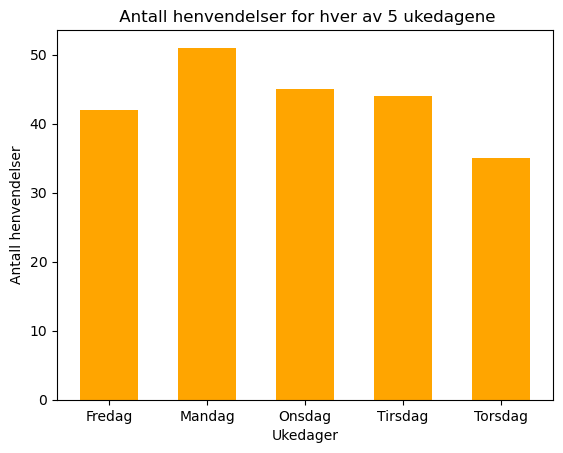

In [175]:
#Del b) Skriv et program som finner antall henvendelser for hver de 5 ukedagene. Resultatet
#visualiseres ved bruk av et søylediagram (stolpediagram).
mandager = 0 # alter.1  telle alle ukedagene som f.eks.mandag
for i in u_dag:
    if i == "Mandag":
        mandager += 1
print ("antall mandager = ", mandager)
# eller 
dagene, counts = np.unique(u_dag, return_counts=True) # alter.2
print(dagene) # ukedagene blir sortert etter alfabetet, 
print(counts)

plt.bar (dagene, counts, color = "orange", width = 0.6) 
plt.title (" Antall henvendelser for hver av 5 ukedagene")
plt.xlabel("Ukedager")
plt.ylabel("Antall henvendelser")
plt.show()

In [176]:
#Del c) Skriv et program som finner minste og lengste samtaletid som er loggført for uke 24.
#Svaret skrives til skjerm med informativ tekst


minste_samtale = min(varighet) # siden alle  samtaletider er i samme 
lengste_samtale = max(varighet)

print("Minste samtaletid er: ", minste_samtale)
print("Lengste samtaletid er: ", lengste_samtale)


Minste samtaletid er:  00:00:59
Lengste samtaletid er:  00:11:28


In [177]:
#Del d) KREVENDE: Skriv et program som regner ut gjennomsnittlig samtaletid basert på alle
#henvendelser i uke 24

def to_seconds(tid): # returnerer antall sekundet i samtaletiden
    #h, m, sec = map(int, tid.split(":"))
    h, m, sec = tid.split(":")
    return int(h)*3600 + int(m)*60 + int(sec)
    
varighet_sek =[] # tom liste for å lagre varighet i sekunder

for st in varighet: #lage en ny array hvor alle samtaletider fremstår i  sekunder
    varighet_sek.append( to_seconds(st))
#print (varighet_sek)

summen_sek = 0
for sek in varighet_sek:
    summen_sek += int (sek)
#print (summen_sek)

gjennomsnittsamtaletid = summen_sek / len(varighet_sek) #Summere alle tider i sekunder og dele på antall samtaler

print ( "Gjennomsnittlig samtaletid basert på alle henvendelser i uke 24 er ", round (gjennomsnittsamtaletid ), "sek.")
hours, remainder = (divmod(gjennomsnittsamtaletid , 3600))
minutes, seconds = divmod(remainder, 60)

print(" eller" , int(hours),"timer",  int(minutes),"minutter og ", int (seconds), "sekunder") # gi gjennomsnittsamtaletid i samme format som andre
 

Gjennomsnittlig samtaletid basert på alle henvendelser i uke 24 er  400 sek.
 eller 0 timer 6 minutter og  40 sekunder


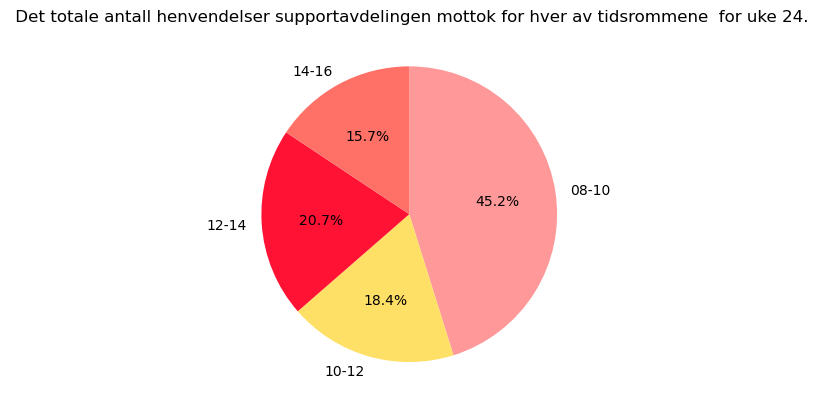

In [181]:
#Del e) Supportvaktene i MORSE er delt inn i 2-timers bolker: kl 08-10, kl 10-12, kl 12-14 og kl
#14-16. Skriv et program som finner det totale antall henvendelser supportavdelingen mottok
#for hver av tidsrommene 08-10, 10-12, 12-14 og 14-16 for uke 24. Resultatet visualiseres ved
#bruk av et sektordiagram (kakediagram).

tidsrom_8_10  = 0 #telle antall henvendelser fra 0 av
tidsrom_10_12 = 0
tidsrom_12_14 = 0
tidsrom_14_16 = 0

for kl in kl_slett:
    h, m, sec = kl.split(":")
    if 8 <= int(h) < 10 : #tidsrom 8-10
        tidsrom_8_10 += 1
    if 10 <= int(h) < 12 : #tidsrom 10-12
        tidsrom_10_12 += 1
    if 12 <= int(h) < 14 : #tidsrom 12-14
        tidsrom_12_14 += 1
    if 14 <= int(h) < 16 : #tidsrom 14-16
        tidsrom_14_16 += 1

antall_henvendelser =[tidsrom_8_10, tidsrom_10_12, tidsrom_12_14, tidsrom_14_16 ] #liste med antall henvendelser etter tidsrommene
colors = ['#ff9999', '#ffe066', '#ff1234', '#ff7066']
tidsrommene = ["08-10", "10-12", "12-14", "14-16"]
plt.pie( antall_henvendelser , colors = colors, labels = tidsrommene, autopct= "%1.1f%%", startangle=90, counterclock=False)
plt.title (" Det totale antall henvendelser supportavdelingen mottok for hver av tidsrommene  for uke 24.")
plt.show ()


In [182]:
#Del f) Kundens tilfredshet loggføres som tall fra 1-10 hvor 1 indikerer svært misfornøyd og
#10 indikerer svært fornøyd. Disse tilbakemeldingene skal så overføres til NPS-systemet (Net Promoter Score).
#Lag et program som regner ut supportavdelings NPS og skriver svaret til skjerm.
antall_tilbakemeldinger = 0
negative_kunder = 0
positive_kunder = 0
for kunde in score:
      if not(np.isnan(kunde)): #hvis tilbakemeldingen ikke er nan
        antall_tilbakemeldinger += 1 # teller Kunder som  har gitt tilbakemelding på tilfredshet
        if kunde > 9:
            positive_kunder += 1 # teller antall positive kunder (score 9-10)
        if kunde <= 6:
            negative_kunder += 1 # teller antall negative kunder (score 1-6)
            
#print (antall_tilbakemeldinger,  positive_kunder, negative_kunder)      
prosent_positive =  round (positive_kunder  / antall_tilbakemeldinger *100,1) # hvor mane % av kundene er positive?
prosent_negative =  round (negative_kunder / antall_tilbakemeldinger *100,1) # hvor mane % av kundene er negative?

NPS =  round( prosent_positive - prosent_negative,1)  # NPS = % positive kunder - % negative kunder
print ( "Prosent kundene som er positive: ", prosent_positive, "%")
print ( "Prosent kundene som er negative: ", prosent_negative, "%")
print ( "Supportavdelingens NPS (Net Promoter Score): ", NPS, "%")


Prosent kundene som er positive:  41.9 %
Prosent kundene som er negative:  23.3 %
Supportavdelingens NPS (Net Promoter Score):  18.6 %
